# Real-Time Gesture Typing - Model Training

This notebook is used for experimentation, including dataset exploration, preprocessing, data augmentation, and model training.

The final implementation of the project is organized in standalone Python scripts (`.py`), which use the trained model for real-time gesture recognition.

## Imports

In [1]:
import os
from keras.utils import load_img, img_to_array
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Import Dataset

In [2]:

# pasta base com subpastas A, B, C, ...
base_folder = "./data/asl_alphabet_train"

# dataset de treino (80%) e validação (20%)
batch_size = 64
img_size = [128, 128]

ds_train_ = tf.keras.utils.image_dataset_from_directory(
    base_folder,
    labels='inferred',          # labels vêm das subpastas
    label_mode='categorical',   # 29 classes → one-hot
    validation_split=0.2,       # 20% validação
    subset="training",
    seed=42,                    # para divisão reproducível
    image_size=img_size,
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True
)

ds_valid_ = tf.keras.utils.image_dataset_from_directory(
    base_folder,
    labels='inferred',
    label_mode='categorical',
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)

# Data Pipeline
def convert_to_float(image, label):
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    return image, label

AUTOTUNE = tf.data.experimental.AUTOTUNE
ds_train = (
    ds_train_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)
ds_valid = (
    ds_valid_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

Found 87000 files belonging to 29 classes.
Using 69600 files for training.
Found 87000 files belonging to 29 classes.
Using 17400 files for validation.


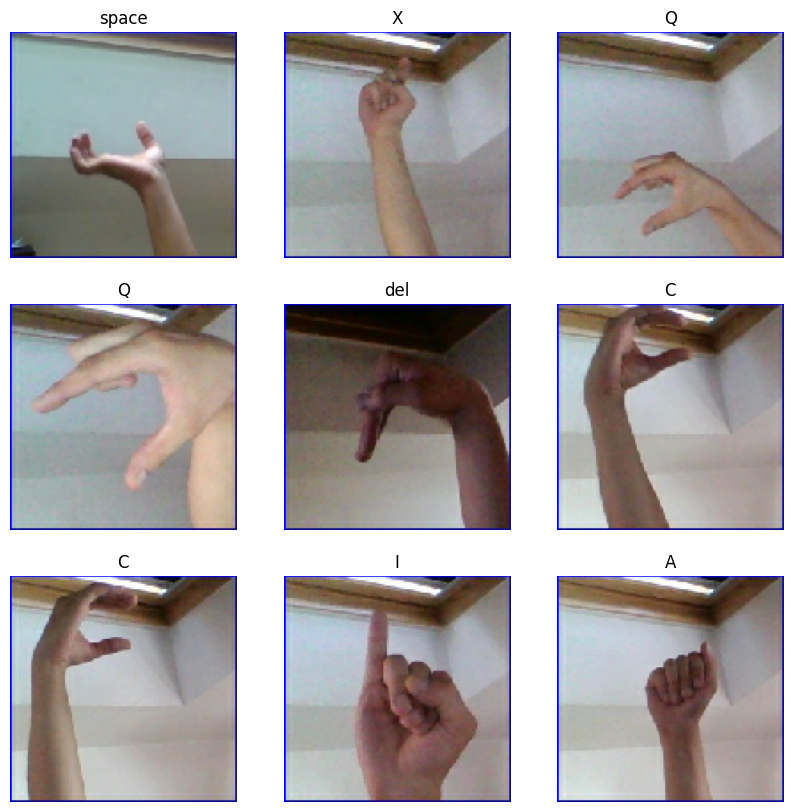

In [3]:
class_names = ds_train_.class_names  # lista de nomes das classes

for images, labels in ds_train.take(1):
    images = tf.clip_by_value(images, 0.0, 1.0)  # garante que matplotlib não queixa
    plt.figure(figsize=(10,10))
    for i in range(9):
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy())
        label_index = tf.argmax(labels[i]).numpy()
        plt.title(class_names[label_index])  # mostra o nome da classe
        plt.axis("off")
    plt.show()
    break

## Data Augmentation

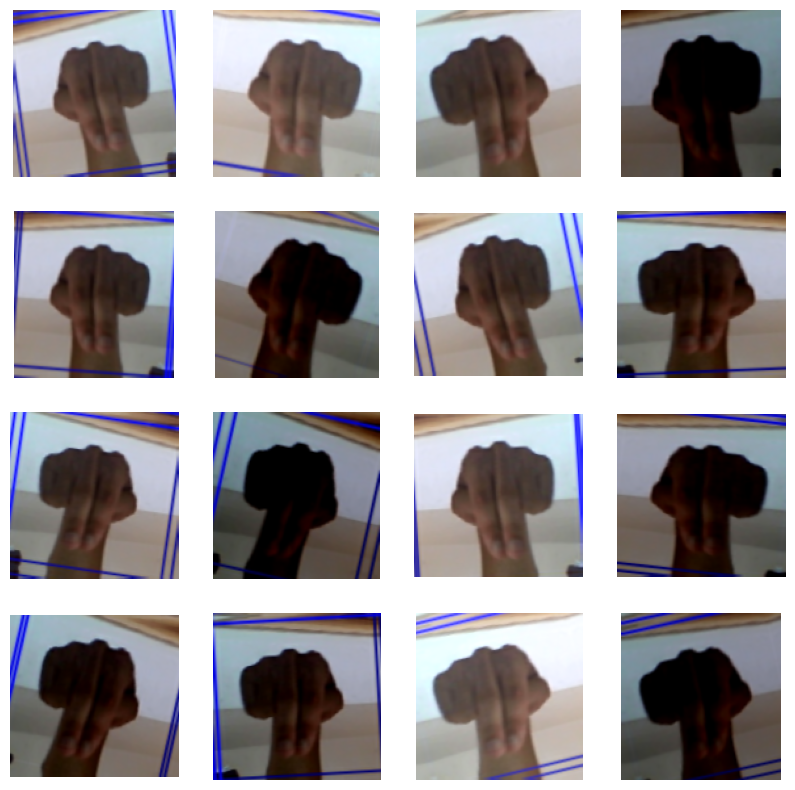

In [4]:
augment = keras.Sequential([
    layers.RandomContrast(factor=0.2),
    layers.RandomZoom(height_factor=0.1, width_factor=0.1),
    layers.RandomBrightness(factor=0.001),
    #layers.RandomSaturation(factor=0.002),
    layers.RandomFlip(mode='horizontal'), # meaning, left-to-right
    #layers.RandomFlip(mode='vertical'), # meaning, top-to-bottom
    layers.RandomWidth(factor=0.05), # horizontal stretch
    layers.RandomRotation(factor=0.05),
    layers.RandomTranslation(height_factor=0.01, width_factor=0.01),
])


ex = next(iter(ds_train.unbatch().map(lambda x, y: x).batch(1)))

plt.figure(figsize=(10,10))
for i in range(16):
    image = augment(ex, training=True)
    image = tf.clip_by_value(image, 0.0, 1.0)  # força 0..1
    plt.subplot(4, 4, i+1)
    plt.imshow(tf.squeeze(image))
    plt.axis('off')
plt.show()

## Model

### No pretrained (Don't run cell below)

In [ ]:
#Model with no pretrained weights
model = keras.Sequential([
    layers.InputLayer(shape = [128, 128, 3]),

    #Data Augmentation
    layers.RandomContrast(factor=0.2),
    layers.RandomZoom(height_factor=0.1, width_factor=0.1),
    layers.RandomBrightness(factor=0.001),
    layers.RandomFlip(mode='horizontal'), # meaning, left-to-right
    layers.RandomWidth(factor=0.05), # horizontal stretch
    layers.RandomRotation(factor=0.05),
    layers.RandomTranslation(height_factor=0.01, width_factor=0.01),

    #Layers of NN
    #Block 1
    layers.BatchNormalization(),
    layers.Conv2D(
        filters=64,
        kernel_size=3,
        kernel_initializer='he_normal',
        activation='relu',
        padding='same'),
    layers.MaxPool2D(),

    #Block 2
    layers.BatchNormalization(),
    layers.Conv2D(
        filters=128,
        kernel_size=3,
        kernel_initializer='he_normal',
        activation='relu',
        padding='same'),
    layers.MaxPool2D(),    
    
    #Block 3
    layers.BatchNormalization(),
    layers.Conv2D(
        filters=256,
        kernel_size=3,
        kernel_initializer='he_normal',
        activation='relu',
        padding='same'),
    layers.Conv2D(
        filters=256,
        kernel_size=3,
        kernel_initializer='he_normal',
        activation='relu',
        padding='same'),
    layers.MaxPool2D(),

    #Dense layers - Head
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.0005)),
    layers.Dropout(0.2),
    layers.Dense(29,activation='softmax', kernel_regularizer=regularizers.l2(0.0005))
])

### Pretrained Model

In [5]:
#model with pretrained weights

# =========================
# Data Augmentation
# =========================
data_augmentation = keras.Sequential([
    layers.RandomContrast(factor=0.2),
    layers.RandomZoom(height_factor=0.1, width_factor=0.1),
    layers.RandomBrightness(factor=0.001),
    layers.RandomFlip(mode='horizontal'), # meaning, left-to-right
    layers.RandomWidth(factor=0.05), # horizontal stretch
    layers.RandomRotation(factor=0.05),
    layers.RandomTranslation(height_factor=0.01, width_factor=0.01)
])

# =========================
# Base model (pre-trained)
# =========================
base_model = keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

# Freeze base model (fase 1)
base_model.trainable = False

# =========================
# Head (classificador)
# =========================
inputs = keras.Input(shape=(128, 128, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(29, activation='softmax')(x)

model = keras.Model(inputs, outputs)

### Compile

In [6]:
optimizer = tf.keras.optimizers.Adam(epsilon=1e-3)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        #Precision(name='precision'),
        #Recall(name='recall')
    ]
)

# callbacks for fase 1
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.4,
    patience=3
)

# callbacks for fase 2
early_stop_ = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr_ = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.4,
    patience=3
)

### Train

In [7]:
#small_ds_train = ds_train.take(430)  # test the model with 430 batches (27520 images, 40% of train) 
#small_ds_valid = ds_valid.take(108)   # validation with 40% of the validation set (6912 images)

model.fit(
    ds_train,
    validation_data=ds_valid,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

for layer in base_model.layers[-40:]:
    layer.trainable = True

# Re-compile com LR baixo
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Treinar novamente
model.fit(
    ds_train,
    validation_data=ds_valid,
    epochs=20,
    callbacks=[early_stop_, reduce_lr_]
)

Epoch 1/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 700s 639ms/step - accuracy: 0.7268 - loss: 0.8986 - val_accuracy: 0.9280 - val_loss: 0.2228 - learning_rate: 0.0010
Epoch 2/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 704s 647ms/step - accuracy: 0.8435 - loss: 0.4785 - val_accuracy: 0.9614 - val_loss: 0.1359 - learning_rate: 0.0010
Epoch 3/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 673s 619ms/step - accuracy: 0.8628 - loss: 0.4211 - val_accuracy: 0.9717 - val_loss: 0.0863 - learning_rate: 0.0010
Epoch 4/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 679s 624ms/step - accuracy: 0.8745 - loss: 0.3796 - val_accuracy: 0.9622 - val_loss: 0.1355 - learning_rate: 0.0010
Epoch 5/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 682s 627ms/step - accuracy: 0.8820 - loss: 0.3571 - val_accuracy: 0.9582 - val_loss: 0.1382 - learning_rate: 0.0010
Epoch 6/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 672s 617ms/step - accuracy: 0.8889 - loss: 0.3379 - val_accuracy: 0.9593 - val_loss: 0.1387 - learning_rate: 0.0010
Epoch 7/20
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 668s 614ms

## Test model

In [8]:
import numpy as np
# pasta base com subpastas A, B, C, ...
test_folder = "./data/asl_alphabet_test"


class_names = ds_train_.class_names

X = []
y = []

for file in os.listdir(test_folder):
    if file.endswith(".jpg"):
        # label: "A_test.jpg" -> "A"
        label = file.split("_")[0]

        # imagem
        img = load_img(os.path.join(test_folder, file), target_size=img_size)
        img = img_to_array(img) / 255.0

        X.append(img)
        y.append(class_names.index(label))

X = np.array(X)
y = np.array(y)
len(X), len(y)

(29, 29)

In [9]:
preds = model.predict(X)
pred_classes = np.argmax(preds, axis=1)

for i in range(len(X)):
    print(f"Real: {class_names[y[i]]} | Pred: {class_names[pred_classes[i]]}")

accuracy = np.mean(pred_classes == y)
print(f"Test Accuracy: {accuracy:.2%} -> {len(np.where(pred_classes == y)[0])}/{len(y)} right")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Real: A | Pred: A
Real: B | Pred: B
Real: C | Pred: C
Real: del | Pred: del
Real: D | Pred: D
Real: E | Pred: E
Real: F | Pred: F
Real: G | Pred: G
Real: H | Pred: H
Real: I | Pred: I
Real: J | Pred: J
Real: K | Pred: K
Real: L | Pred: L
Real: M | Pred: M
Real: nothing | Pred: nothing
Real: N | Pred: N
Real: O | Pred: O
Real: P | Pred: P
Real: Q | Pred: Q
Real: R | Pred: R
Real: space | Pred: space
Real: S | Pred: S
Real: T | Pred: T
Real: U | Pred: U
Real: V | Pred: V
Real: W | Pred: W
Real: X | Pred: X
Real: Y | Pred: Y
Real: Z | Pred: Z
Test Accuracy: 100.00% -> 29/29 right


In [10]:
model.save("models/model_v1.keras")

In [11]:
with open("experiments_log.txt", "a") as f:
    f.write("""
==============================
Model: model_v1
- img_size: 128
- batch_size: 64
- augmentation: Contrast(0.2), Zoom(0.1/0.1), Brightness(0.001), Flip('horizontal'), Width(0.05), Rotation(0.05),Translation(0.01/0.01)
- model: pretrained model (MobileNetV2) + GAP, dense 128(activation='relu') + dropout 30%, dense 29(activation='softmax')
- result: acc=0.9851  loss=0.0455 / val_acc=0.9963  val_loss=0.0103
- prediction: 100% -> 29/29 right
- notes:
        The model architecture was based on a pre-trained MobileNetV2 as the base, with a custom head. 
        This model was trained with full dataset, training for 20 epochs(stopped after 8 epochs).
        The model was then fine-tuned with the last 40 layers of the base model unfrozen, and trained for 20 more epochs with a lower learning rate (stopped after 20 epochs with 19 epoch being the best).
        After the training, the model achieved an accuraçy of 98.51% and loss of 0.0455 on training and 99.63% accuracy and loss of 0.0103 on validation.
        This is the first version of the final model.
            
==============================
""")



In [4]:
modelo = tf.keras.models.load_model("models/model_v1.keras")
modelo.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 128, None, 3)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, None, 1280)  │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,134,425 (23.40 MB)

 Trainable params: 1,851,805 (7.06 MB)

 Non-trainable params: 579,008 (2.21 MB)

 Optimizer params: 3,703,612 (14.13 MB)